In [1]:
import pandas as pd
import os
# change directory one up
os.chdir('..')

In [ ]:
# list all files in results/test_varying
files = os.listdir('results/test_varying/data=Custom_dataset,experiment=test_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=0,random_state=2021,relevance=linear,relevance_tower=linear')


def load_and_concat_shift_files(folder_path, prefix, column_name):
    """
    Load CSV files from folder_path that start with prefix, sort them based on the number
    at the end of the filename, add a column with that number, and concatenate all into a single DataFrame.
    
    Args:
        folder_path (str): Path to the folder containing the CSV files.
        prefix (str): Prefix of the files to include.
        column_name (str): Name of the new column to store the shift number.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame of all relevant CSVs with shift column added.
    """
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[-1].replace('.csv','')))
    
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name] = float(f.split('_')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    
    return combined_df


folder_path = 'results/test_varying/data=Custom_dataset,experiment=test_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=0,random_state=2021,relevance=linear,relevance_tower=linear'

multi_relevance_df = load_and_concat_shift_files(folder_path, 'relevance_param_shift', 'relevance_param_shift')
multi_performance_df = load_and_concat_shift_files(folder_path, 'test_clicks_param_shift', 'test_clicks_param_shift')

In [37]:
multi_relevance_df.relevance_param_shift.unique()

array([-3. , -2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,
        2.5,  3. ])

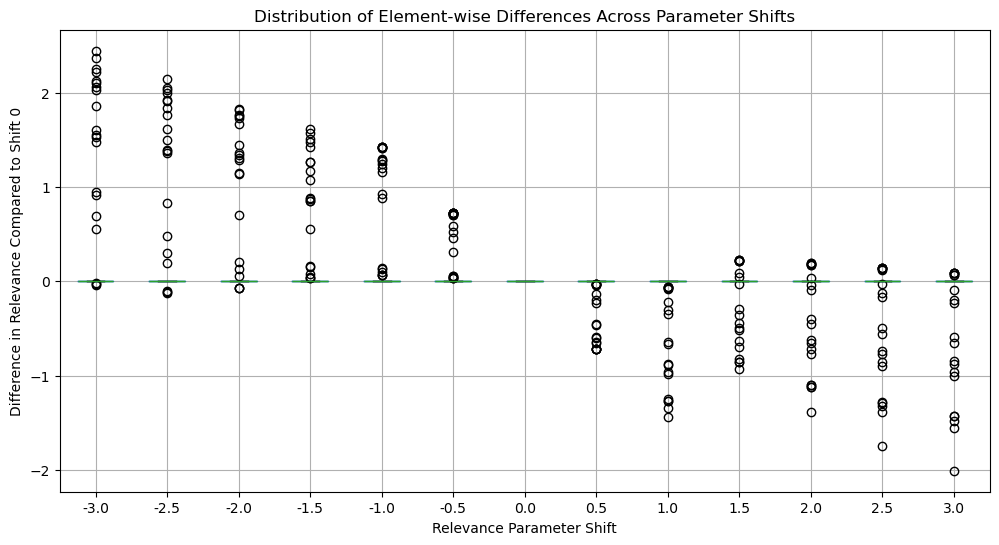

In [38]:
import matplotlib.pyplot as plt

# Step 1: get relevance values at shift 0
baseline = multi_relevance_df[multi_relevance_df['relevance_param_shift'] == 0]['relevance'].reset_index(drop=True)

# Step 2: create an empty DataFrame to store differences
diff_df = pd.DataFrame()

# Step 3: compute difference for each shift
for shift in multi_relevance_df['relevance_param_shift'].unique():
    values = multi_relevance_df[multi_relevance_df['relevance_param_shift'] == shift]['relevance'].reset_index(drop=True)
    diff_df[shift] = values - baseline  # element-wise difference

# Step 4: plot boxplot of differences
plt.figure(figsize=(12, 6))
diff_df.boxplot(grid=True)

plt.xlabel('Relevance Parameter Shift')
plt.ylabel('Difference in Relevance Compared to Shift 0')
plt.title('Distribution of Element-wise Differences Across Parameter Shifts')
plt.show()

In [43]:
multi_performance_df

,nll,loss,test_clicks_param_shift
0,0.302319,0.302319,-1.0
0,0.304264,0.304264,-0.5
0,0.309751,0.309751,0.0
0,0.319948,0.319948,0.5
0,0.339678,0.339678,1.0


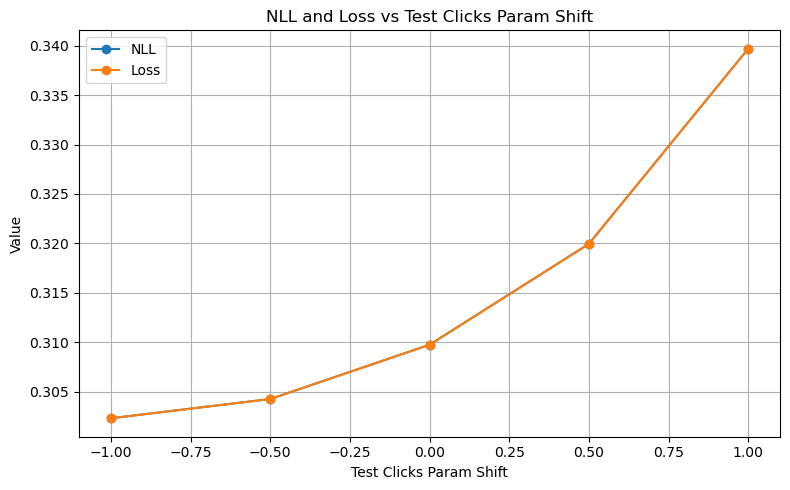

In [42]:
# sort by the shift parameter
multi_performance_df = multi_performance_df.sort_values('test_clicks_param_shift')

plt.figure(figsize=(8,5))

# plot NLL
plt.plot(multi_performance_df['test_clicks_param_shift'], 
         multi_performance_df['nll'], 
         marker='o', label='NLL')

# plot Loss
plt.plot(multi_performance_df['test_clicks_param_shift'], 
         multi_performance_df['loss'], 
         marker='o', label='Loss')

plt.xlabel('Test Clicks Param Shift')
plt.ylabel('Value')
plt.title('NLL and Loss vs Test Clicks Param Shift')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
